In [901]:
from keras.datasets import fashion_mnist as fm;
from keras.utils import to_categorical
from keras import layers,models,regularizers
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# สร้าง List ของ Class label เพื่อทำ Word indice
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [ ]:
# Load data from dataset
(train_x,train_y),(test_x,test_y) = fm.load_data()

In [904]:
print(f"train_x.shape : {train_x.shape}")
print(f"train_y.shape : {train_y.shape}")
print(f"test_x.shape : {test_x.shape}")
print(f"test_y.shape : {test_y.shape}")

train_x.shape : (60000, 28, 28)
train_y.shape : (60000,)
test_x.shape : (10000, 28, 28)
test_y.shape : (10000,)


In [922]:
# Reshape and Normalize
train_x = train_x.reshape((60000,28*28)).astype('float')/255.0
test_x = test_x.reshape((10000,28*28)).astype('float')/255.0

In [ ]:
# แบ่ง Train กับ Validation
val_x = train_x[40000:]
val_y = train_y[40000:]

train_x = train_x[:40000]
train_y = train_y[:40000]

In [907]:
print(f"train_x.shape : {train_x.shape}")
print(f"train_y.shape : {train_y.shape}")
print(f"val_x.shape : {val_x.shape}")
print(f"val_y.shape : {val_y.shape}")
print(f"test_x.shape : {test_x.shape}")
print(f"test_y.shape : {test_y.shape}")

train_x.shape : (40000, 784)
train_y.shape : (40000,)
val_x.shape : (20000, 784)
val_y.shape : (20000,)
test_x.shape : (10000, 784)
test_y.shape : (10000,)


In [ ]:
# Model Definition ด้วย .Sequential(...) แล้วกำหนด layer ด้วย layers.Dense(NeuronNumber,ActivationFunction) เป็นการสร้างโครงสร้าง Neuron Network
model = models.Sequential([
    layers.Dense(256,activation='relu',input_shape=(784,)) ,
    layers.Dense(256,activation='relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(10,activation='softmax')
])

# Compile model ด้วย model.compile(optimizer,loss,metrics) เป็นการกำหนดรายละเอียดการเทรนโมเดล
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
# Fit Model เป็นการสั่งเทรนโมเดล
history = model.fit(train_x,train_y,epochs=30,batch_size=3000,validation_data=(val_x,val_y))

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5066 - loss: 1.4390 - val_accuracy: 0.7199 - val_loss: 0.8242
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7570 - loss: 0.6923 - val_accuracy: 0.7940 - val_loss: 0.5960
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8102 - loss: 0.5502 - val_accuracy: 0.8184 - val_loss: 0.5174
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8298 - loss: 0.4899 - val_accuracy: 0.8363 - val_loss: 0.4743
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8428 - loss: 0.4549 - val_accuracy: 0.8409 - val_loss: 0.4505
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8502 - loss: 0.4299 - val_accuracy: 0.8393 - val_loss: 0.4502
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8544 - loss: 0.4166 - val_accuracy: 0.8521 - val_loss: 0.4189
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8622 - loss: 0.3962 - val_accuracy: 0.8535 - val_los

In [911]:
def plot(history,name="") :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(15,7))
    
    plt.subplot(1,2,1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1,2,2)
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
    print(f"min val_loss : {min(val_loss)}")
    print(f"max val_acc : {max(val_accuracy)}")
    print(f"Latest val_loss : {val_loss[len(val_loss)-1]}")
    print(f"Latest val_acc : {val_accuracy[len(val_accuracy)-1]}")

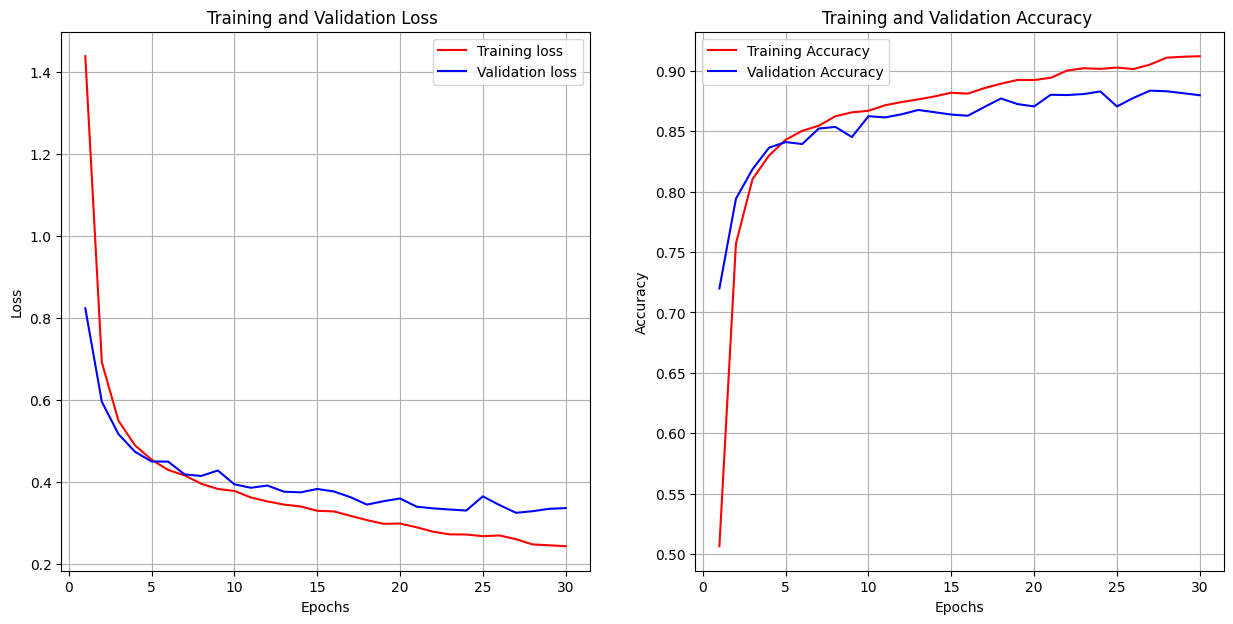

min val_loss : 0.3254053294658661
max val_acc : 0.8834499716758728
Latest val_loss : 0.336845725774765
Latest val_acc : 0.8796499967575073
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - accuracy: 0.8732 - loss: 0.3645
Evaluate Loss : 0.3644888401031494 , Evaluate Acc : 0.873199999332428


In [924]:
# สั่ง plot graph 
plot(history)
loss , acc = model.evaluate(test_x,test_y)
print(f"Evaluate Loss : {loss} , Evaluate Acc : {acc}")

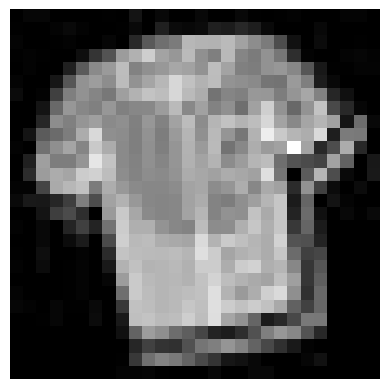

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted : Shirt
ความมั่นใจ: 41.99%


In [913]:
filename = f"Shirt.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {class_names[predicted_digit]}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

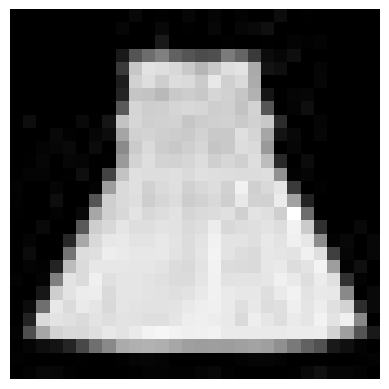

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Predicted : Dress
ความมั่นใจ: 45.05%


In [914]:
filename = f"Dress.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {class_names[predicted_digit]}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

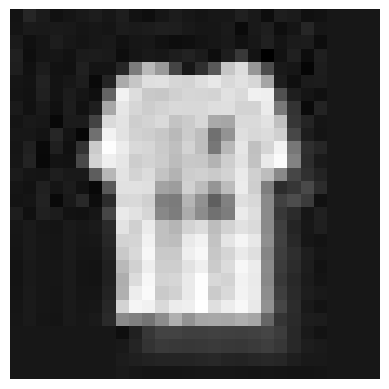

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Predicted : T-shirt/top
ความมั่นใจ: 54.29%


In [915]:
filename = f"T-shirt.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {class_names[predicted_digit]}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

ตอบคำถามอาจารย์

1. แสดงรูป train[55] และ label ของภาพ

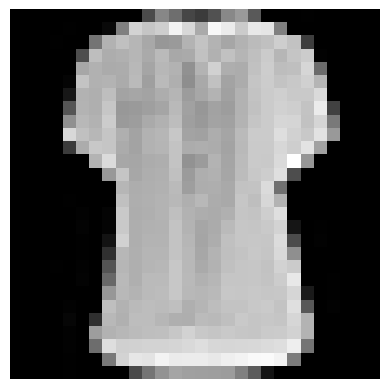

Shirt


In [916]:
plt.imshow(train_x[55].reshape(28,28),cmap='gray')
plt.axis('off')
plt.show()
print(class_names[train_y[55]])

2. แสดง loss & accuracy graph

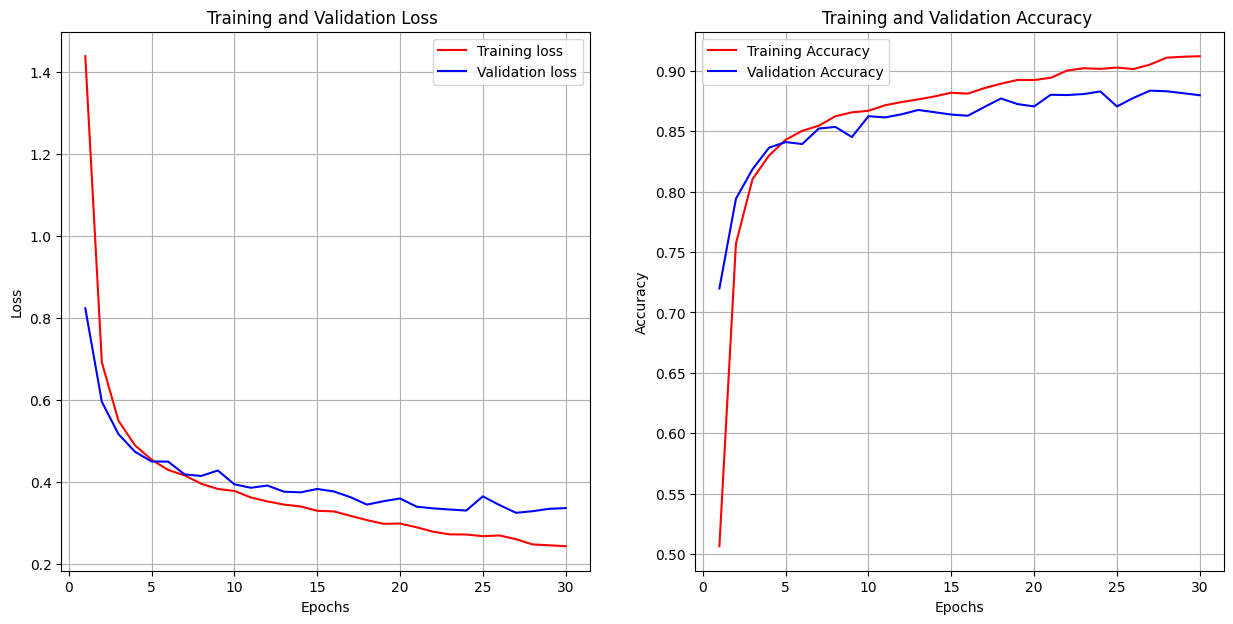

min val_loss : 0.3254053294658661
max val_acc : 0.8834499716758728
Latest val_loss : 0.336845725774765
Latest val_acc : 0.8796499967575073


In [917]:
plot(history)

3. ระบุค่า Epoch ที่เหมาะสม

    ใช้ Epoch 30 รอบ

4. แสดง accuracy ของ test dataset

In [918]:
loss , acc = model.evaluate(test_x,test_y)
print(loss,acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step - accuracy: 0.8732 - loss: 0.3645
0.3644888401031494 0.873199999332428


5. แสดงผลการทำนายภาพที่ให้ทดสอบ 3 ภาพ ใน code และบันทึกผลในลิ้งค์ข้อ 5 ด้วย อธิบายใน comment ได้ทำไมผิด

    ถูกต้องทั้งหมด